In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"D:\Downloads\playground-series-s6e7\train.csv")
df

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [5]:
df.describe()    #Statistical view

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [18]:
df.drop("id", axis=1, inplace=True)

In [19]:
df

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [ ]:
# EDA: shape, dtypes, missing values
print(df.shape)
df.info()
df.isnull().sum()

(690088, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  object 
 1   sleep_duration           614089 non-null  float64
 2   heart_rate               682255 non-null  float64
 3   bmi                      676190 non-null  float64
 4   calorie_expenditure      637235 non-null  float64
 5   step_count               676172 non-null  float64
 6   exercise_duration        683187 non-null  float64
 7   water_intake             646611 non-null  float64
 8   diet_type                683187 non-null  object 
 9   stress_level             607277 non-null  object 
 10  sleep_quality            631757 non-null  object 
 11  physical_activity_level  653467 non-null  object 
 12  smoking_alcohol          661506 non-null  object 
 13  gender                   668715 non-null  obje

health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

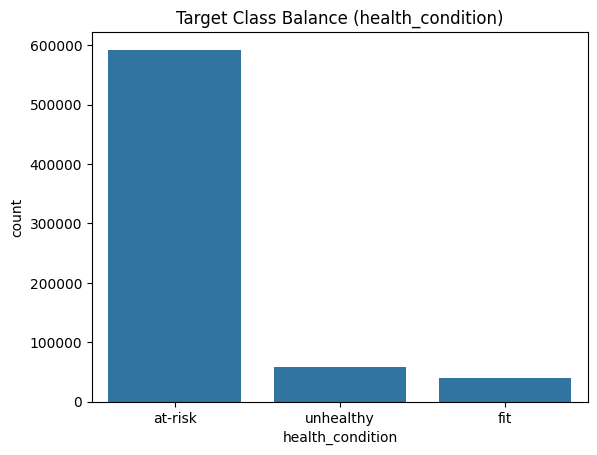

health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64

In [ ]:
# Target class balance
sns.countplot(data=df, x='health_condition', order=df['health_condition'].value_counts().index)
plt.title('Target Class Balance (health_condition)')
plt.show()

df['health_condition'].value_counts(normalize=True) * 100

In [ ]:
# Handle missing values: mean for numeric, mode for categorical
num_cols = df.select_dtypes(include='float64').columns
cat_cols = df.select_dtypes(exclude='float64').columns.drop('health_condition')

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

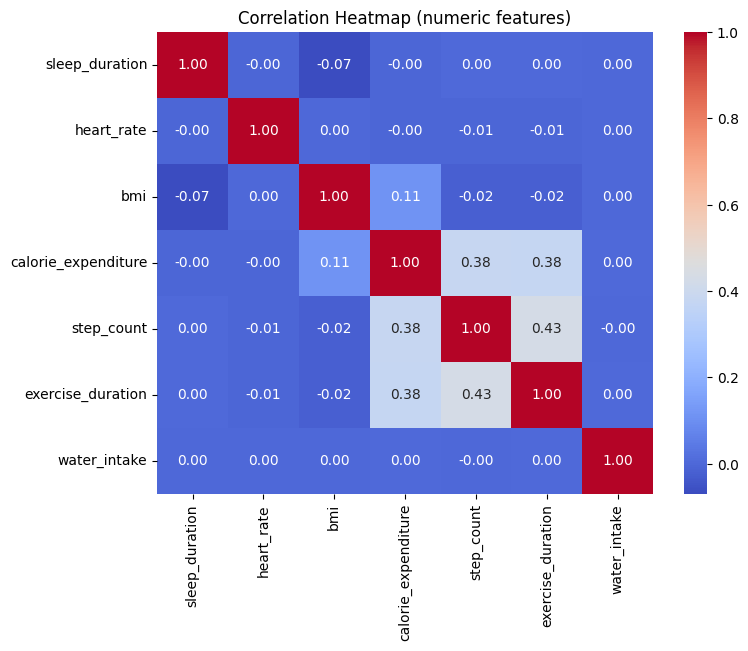

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (numeric features)')
plt.show()

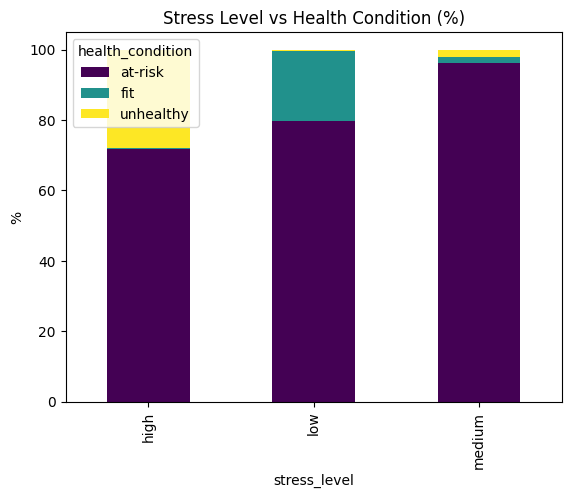

In [ ]:
# Categorical feature vs target (e.g. stress_level)
ct = pd.crosstab(df['stress_level'], df['health_condition'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Stress Level vs Health Condition (%)')
plt.ylabel('%')
plt.show()

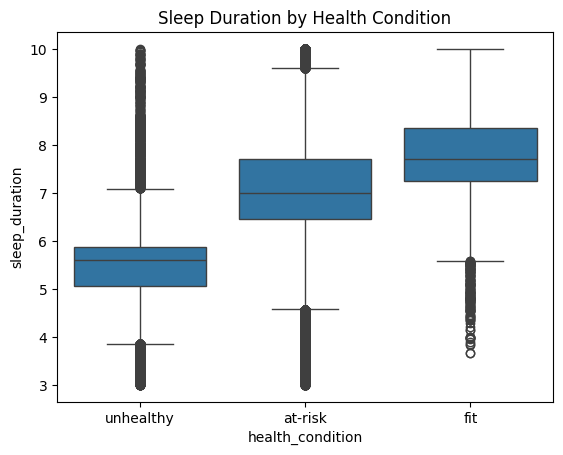

In [ ]:
# Numeric feature distribution by class
sns.boxplot(data=df, x='health_condition', y='sleep_duration')
plt.title('Sleep Duration by Health Condition')
plt.show()

In [ ]:
# Encode categorical values
encoder = LabelEncoder()
categorical_columns = df.select_dtypes(exclude='float64').columns.drop('health_condition')

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,2,0,0,2,2,0
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,1,1,0,1,2,2
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,2,0,2,0,2,1
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,2,0,0,0,1,0
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,2,2,0,2,2,1
